Challenge 1

<ipython-input-1-1936261411>:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)


Error downloading data: 'Adj Close'
Falling back to dummy data for demonstration.
Using dummy data for demonstration.
Sample of dummy daily returns:
                AAPL      MSFT      GOOG      AMZN      NVDA
2020-01-01  0.004967 -0.001383  0.006477  0.015230 -0.002342
2020-01-02 -0.002341  0.015792  0.007674 -0.004695  0.005426
2020-01-03 -0.004634 -0.004657  0.002420 -0.019133 -0.017249
2020-01-06 -0.005623 -0.010128  0.003142 -0.009080 -0.014123
2020-01-07  0.014656 -0.002258  0.000675 -0.014247 -0.005444
Original Data Shape: (250, 5)

Sample of Scaled Returns:
                AAPL      MSFT      GOOG      AMZN      NVDA
2020-01-01  0.511921 -0.093822  0.667288  1.478569 -0.343482
2020-01-02 -0.269829  1.568362  0.791827 -0.572084  0.411382
2020-01-03 -0.515078 -0.410745  0.245321 -2.058026 -1.792310
2020-01-06 -0.620833 -0.940233  0.320499 -1.023432 -1.488490
2020-01-07  1.548335 -0.178517  0.063904 -1.555236 -0.644984

Extracted Principal Components (First 2 components):
        

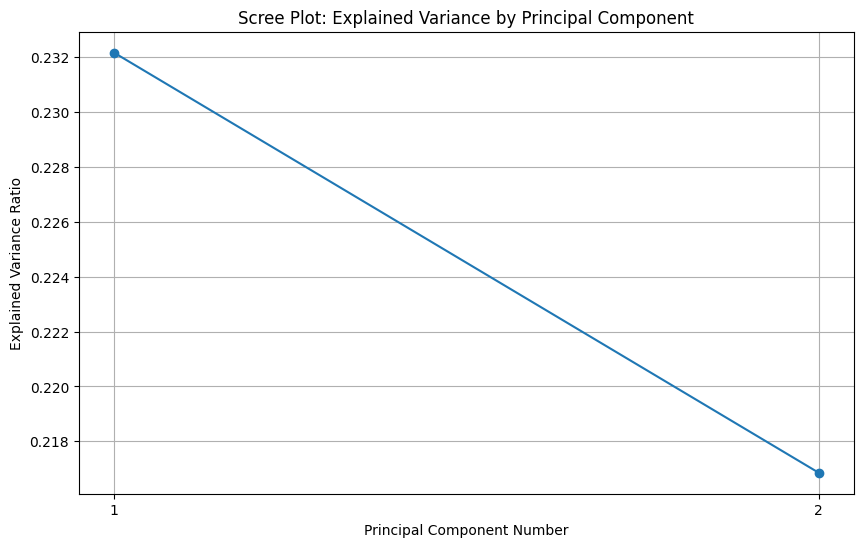

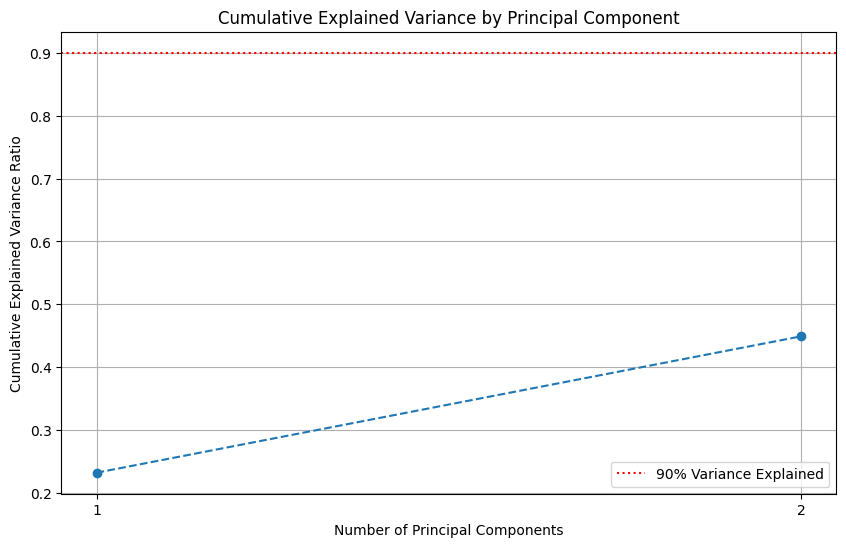

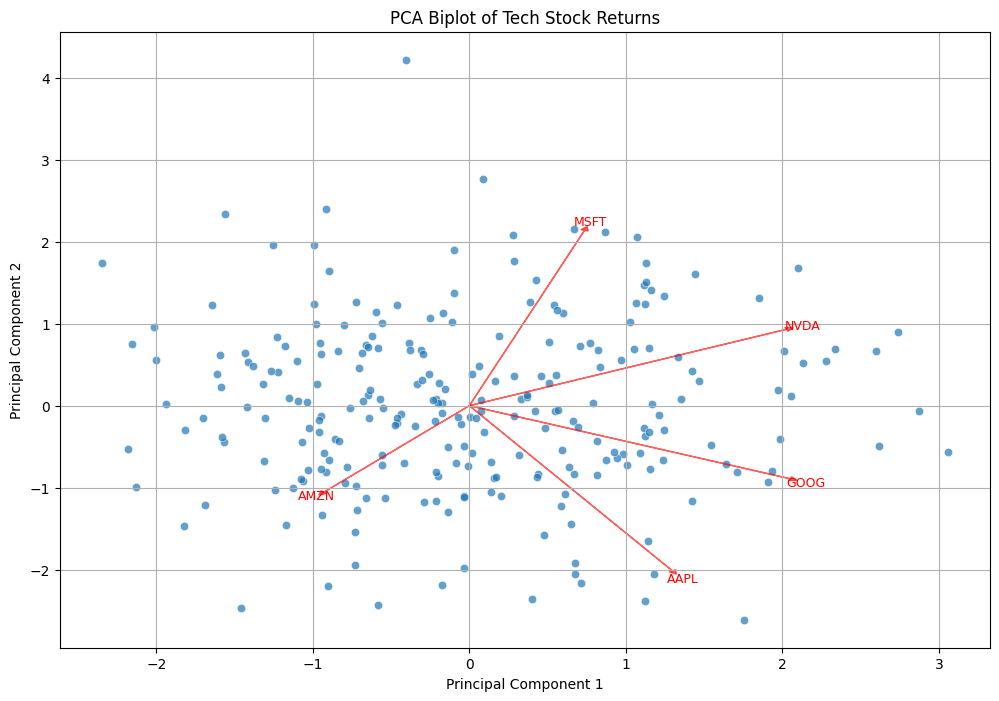

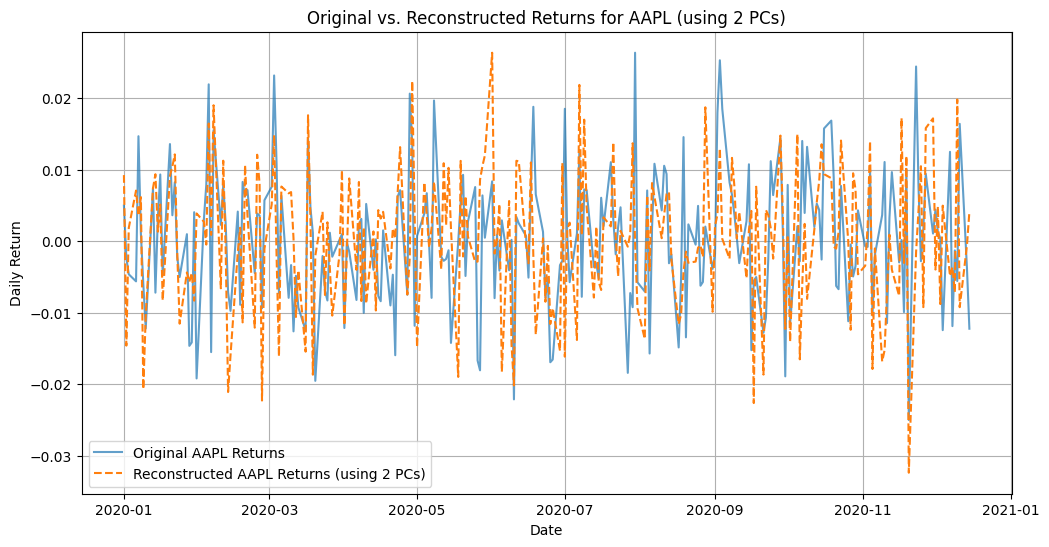


Mean Squared Error of Reconstruction for each feature:
9.660822565600153e-05
Average MSE across all features: 0.000097


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Acquisition ---
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
start_date = '2020-01-01'
end_date = '2025-06-16' # Up to yesterday's close

print(f"Downloading data for {tickers} from {start_date} to {end_date}...")
try:
    data = yf.download(tickers, start=start_date, end=end_date, progress=False)
    # Use Adjusted Close prices and calculate daily returns, as returns are typically used in PCA for financial data
    adj_close = data['Adj Close'].dropna()
    returns = adj_close.pct_change().dropna()

    if returns.empty:
        raise ValueError("No valid data or returns calculated. Check tickers or date range.")
    print("Data downloaded and returns calculated successfully.")
    print("Sample of daily returns:")
    print(returns.head())
    print(f"Original Data Shape: {returns.shape}")

except Exception as e:
    print(f"Error downloading data: {e}")
    print("Falling back to dummy data for demonstration.")
    np.random.seed(42)
    dummy_returns = pd.DataFrame(
        np.random.randn(250, len(tickers)) * 0.01,
        columns=tickers,
        index=pd.bdate_range(start_date, periods=250)
    )
    returns = dummy_returns
    print("Using dummy data for demonstration.")
    print("Sample of dummy daily returns:")
    print(returns.head())
    print(f"Original Data Shape: {returns.shape}")

# --- Data Preprocessing: Scaling ---
# Scaling is crucial for PCA as it's sensitive to the scale of features.
# StandardScaler transforms data to have a mean of 0 and standard deviation of 1.
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns)
scaled_returns_df = pd.DataFrame(scaled_returns, columns=returns.columns, index=returns.index)
print("\nSample of Scaled Returns:")
print(scaled_returns_df.head())

# --- Apply PCA ---
# We'll extract principal components. The number of components (n_components)
# is a key parameter. Let's start by looking at 2 components, often representing
# dominant market factors.
n_components_to_extract = 2
pca = PCA(n_components=n_components_to_extract)
principal_components = pca.fit_transform(scaled_returns_df)

# Create a DataFrame for the principal components for easier handling
principal_df = pd.DataFrame(data=principal_components,
                            columns=[f'PC_{i+1}' for i in range(n_components_to_extract)],
                            index=returns.index)

print(f"\nExtracted Principal Components (First {n_components_to_extract} components):")
print(principal_df.head())
print(f"New Data Shape (after PCA with {n_components_to_extract} components): {principal_df.shape}")

# --- Calibrated Parameters of the Model and Interpretation ---
# 1. Explained Variance Ratio (`pca.explained_variance_ratio_`):
#    This array shows the proportion of the original dataset's variance that
#    is explained by each individual principal component. It's a measure of
#    how much information each component captures.
print("\nExplained Variance Ratio for each Principal Component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC_{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"  Cumulative explained variance by {n_components_to_extract} components: {pca.explained_variance_ratio_.sum():.4f}")

# 2. Principal Components Loadings (`pca.components_`):
#    These are the eigenvectors, representing the linear combination coefficients
#    that define each principal component in terms of the original features.
#    They indicate how much each original stock's return contributes to each PC.
loadings_df = pd.DataFrame(pca.components_, columns=returns.columns,
                           index=[f'PC_{i+1}' for i in range(n_components_to_extract)])
print("\nPrincipal Component Loadings (how original features contribute to PCs):")
print(loadings_df)

# Interpretation:
# - Explained Variance Ratio: If PC1 explains a large proportion (e.g., > 60%), it's a strong
#   indicator of a dominant common factor driving the stock returns. PC2 explains the next
#   largest proportion of remaining variance. A high cumulative explained variance means
#   the extracted features retain most of the original data's information.
# - Loadings: By examining the weights, we can interpret the meaning of each PC.
#   For instance, if PC1 has similar high positive loadings for all tech stocks, it likely
#   represents a general 'tech market factor'. If PC2 has high positive loadings for
#   software stocks and negative for hardware, it might represent a 'software vs. hardware'
#   factor. These extracted features (PCs) are more efficient as they capture shared variance
#   among multiple original features.

# Diagram - Exploratory Plots

# --- Diagram: Exploratory Plots for Feature Extraction (PCA) ---

# 1. Scree Plot: Shows the explained variance by each principal component.
# This helps in deciding the optimal number of components to retain.
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='-')
plt.title('Scree Plot: Explained Variance by Principal Component')
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

# 2. Cumulative Explained Variance Plot: Shows the total variance explained
# as more principal components are added. This helps identify how many components
# are needed to explain a desired percentage of total variance (e.g., 80% or 90%).
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Explained')
plt.legend()
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

# 3. Biplot (if n_components is 2): Visualizes both the data points in the
# new PCA space and the original features as vectors, showing their contribution
# to the components.
if n_components_to_extract == 2:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=principal_df['PC_1'], y=principal_df['PC_2'], alpha=0.7)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA Biplot of Tech Stock Returns')

    # Add feature vectors (loadings)
    # Scale the arrows for better visualization
    scale_factor = max(abs(principal_df['PC_1'].max()), abs(principal_df['PC_2'].max())) * 0.8
    for i, feature in enumerate(returns.columns):
        plt.arrow(0, 0, loadings_df.loc['PC_1', feature] * scale_factor,
                  loadings_df.loc['PC_2', feature] * scale_factor,
                  color='r', alpha=0.6, head_width=0.05, head_length=0.05)
        plt.text(loadings_df.loc['PC_1', feature] * scale_factor * 1.05,
                 loadings_df.loc['PC_2', feature] * scale_factor * 1.05,
                 feature, color='r', fontsize=9, ha='center', va='center')
    plt.grid(True)
    plt.show()

    # Diagnosis- Diagnostic Plots

    # --- Diagnosis: Diagnostic Plots for Feature Extraction (PCA) ---

# 1. Reconstruction Error (Conceptual Visualization):
# This demonstrates how well the original data can be reconstructed from the
# chosen principal components. Lower error indicates better information retention.
# We'll plot one original stock's returns vs. its reconstructed returns.
# (This requires inverse transforming the PCs back to the original feature space)
pca_full = PCA().fit(scaled_returns_df) # Fit PCA with all components to get all eigenvectors
full_principal_components = pca_full.transform(scaled_returns_df)

# Reconstruct data using only the first 'n_components_to_extract' components
reconstructed_data = pca_full.inverse_transform(
    full_principal_components[:, :n_components_to_extract] @ pca_full.components_[:n_components_to_extract, :]
)
reconstructed_df = pd.DataFrame(reconstructed_data, columns=returns.columns, index=returns.index)

# Inverse transform the scaling to compare with original unscaled returns (for visualization)
reconstructed_original_scale = scaler.inverse_transform(reconstructed_df)
reconstructed_original_scale_df = pd.DataFrame(reconstructed_original_scale, columns=returns.columns, index=returns.index)

# Plot original vs. reconstructed for a specific stock (e.g., AAPL)
plt.figure(figsize=(12, 6))
plt.plot(returns.index, returns['AAPL'], label='Original AAPL Returns', alpha=0.7)
plt.plot(reconstructed_original_scale_df.index, reconstructed_original_scale_df['AAPL'], label=f'Reconstructed AAPL Returns (using {n_components_to_extract} PCs)', linestyle='--')
plt.title(f'Original vs. Reconstructed Returns for AAPL (using {n_components_to_extract} PCs)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True)
plt.show()

# Calculate Mean Squared Error of Reconstruction
mse_reconstruction = np.mean((returns - reconstructed_original_scale_df)**2)
print(f"\nMean Squared Error of Reconstruction for each feature:")
print(mse_reconstruction)
print(f"Average MSE across all features: {mse_reconstruction.mean():.6f}")

# Interpretation:
# - A low reconstruction error confirms that the selected principal components effectively
#   capture the essential information from the original high-dimensional data.
# - If the reconstructed plot closely follows the original, it indicates good retention.

Challenge 2

<ipython-input-2-3008185971>:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_coint = yf.download(tickers_coint, start=start_date_coint, end=end_date_coint, progress=False)


Error downloading data: 'Adj Close'
Falling back to dummy data for demonstration.
Using dummy cointegrated-like data for demonstration.
Sample of dummy SPY and IVV prices:
                  SPY        IVV
2010-01-01  47.419923  50.128700
2010-01-04  53.018383  49.674459
2010-01-05  49.943490  49.485208
2010-01-06  50.501820  49.217750
2010-01-07  48.633727  49.646787

--- Testing Individual Series for Non-Stationarity ---

--- ADF Test for SPY Prices ---
  ADF Statistic: -2.9940
  p-value: 0.0355
  Critical Values:
    1%: -3.4437
    5%: -2.8674
    10%: -2.5699
  Conclusion: SPY Prices is likely stationary (Reject H0).

--- ADF Test for IVV Prices ---
  ADF Statistic: -2.1521
  p-value: 0.2241
  Critical Values:
    1%: -3.4435
    5%: -2.8673
    10%: -2.5699
  Conclusion: IVV Prices is likely non-stationary (Fail to Reject H0).

--- OLS Regression (Cointegrating Regression: SPY ~ IVV) ---
                            OLS Regression Results                            
Dep. Variable: 

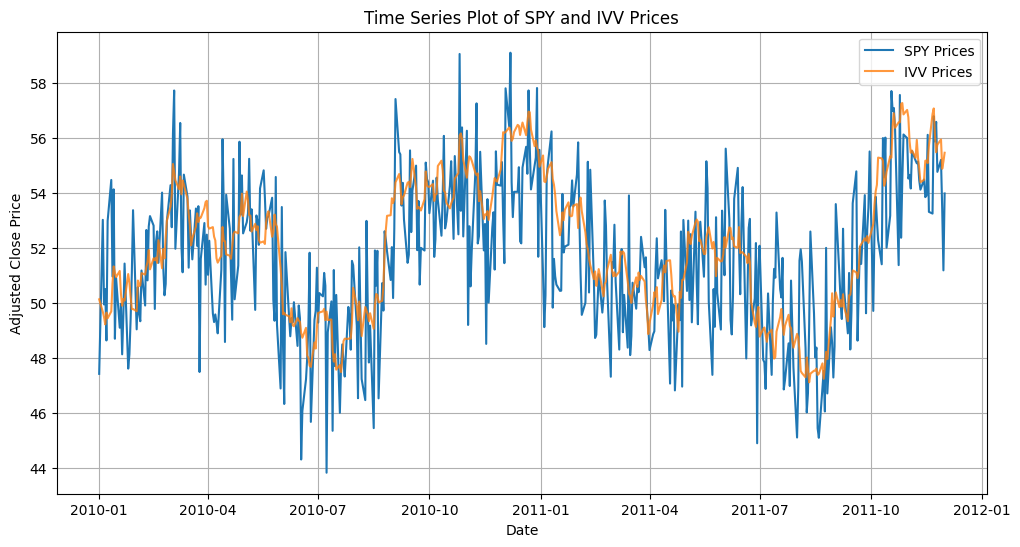

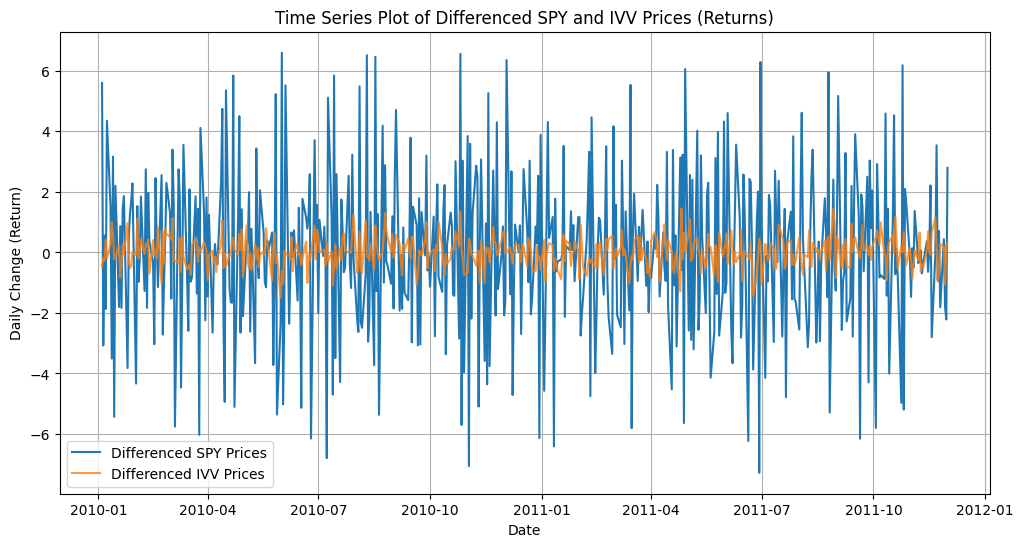

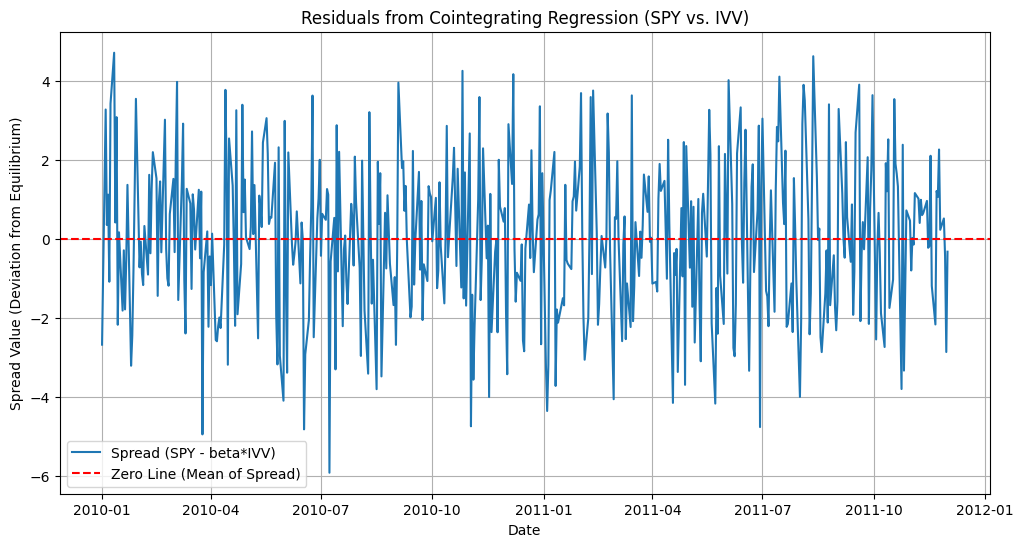

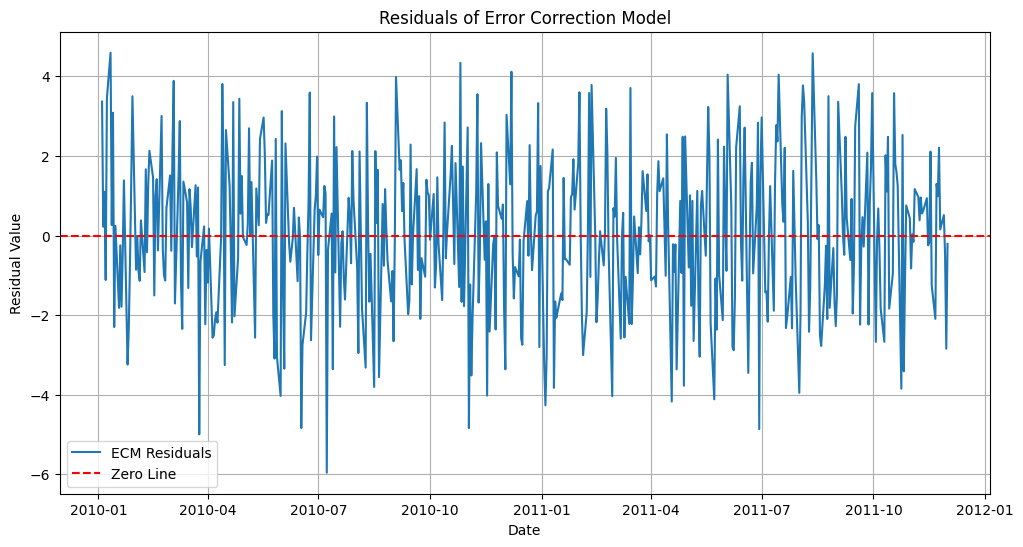

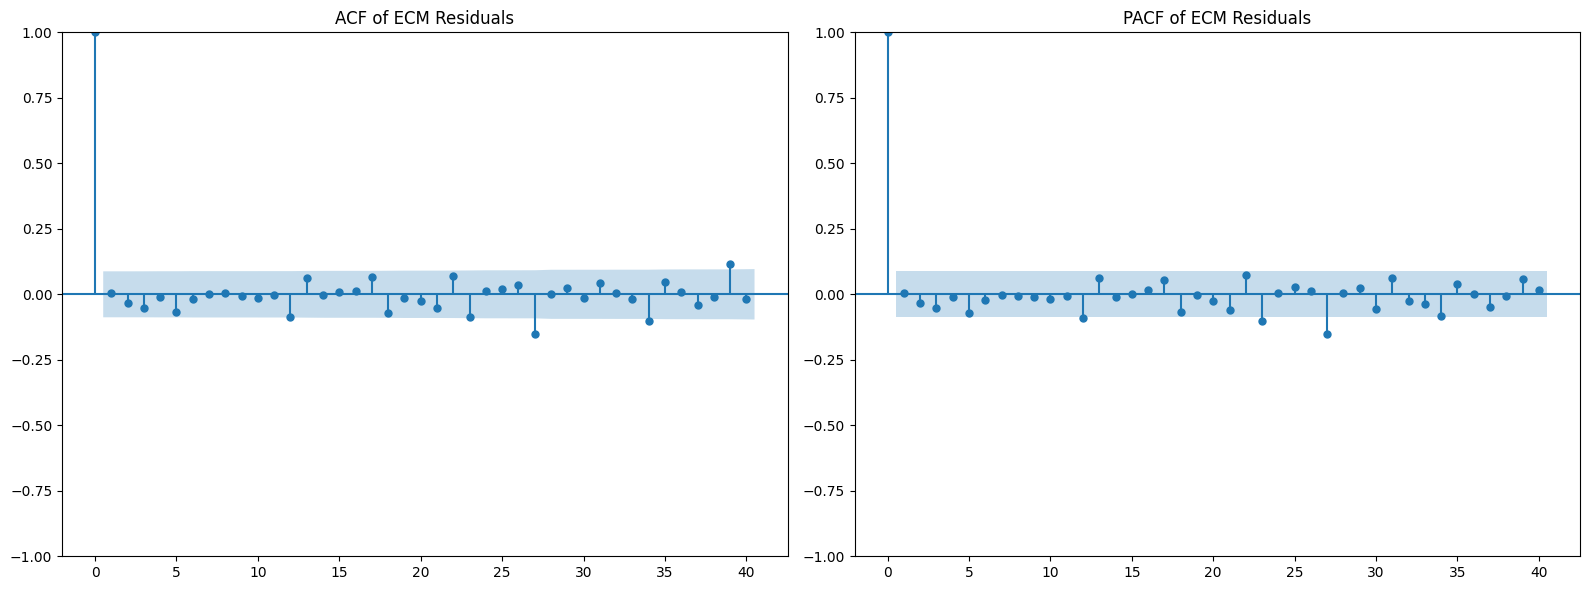

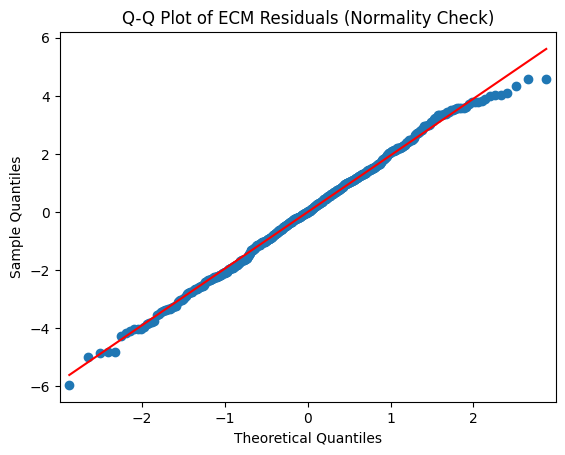


Jarque-Bera Test for ECM Residuals (Normality):
  Statistic: 3.0012, P-value: 0.2230
  Conclusion: Residuals appear to be normally distributed (Fail to Reject H0).

Ljung-Box Test for ECM Residuals (Autocorrelation):
      lb_stat  lb_pvalue
10   4.506232   0.921635
20  15.807840   0.728472
  Conclusion: No significant autocorrelation in residuals (Fail to Reject H0).


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint # Import coint for Engle-Granger
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Acquisition ---
tickers_coint = ['SPY', 'IVV']
start_date_coint = '2010-01-01'
end_date_coint = '2025-06-16'

print(f"\nDownloading data for {tickers_coint} from {start_date_coint} to {end_date_coint}...")
try:
    data_coint = yf.download(tickers_coint, start=start_date_coint, end=end_date_coint, progress=False)
    prices_coint = data_coint['Adj Close'].dropna()

    if prices_coint.empty or len(prices_coint) < 50: # Ensure enough data for reliable tests
        raise ValueError("Not enough valid data for cointegration. Check tickers or date range.")
    print("Data downloaded successfully for cointegration analysis.")
    print("Sample of SPY and IVV prices:")
    print(prices_coint.head())

except Exception as e:
    print(f"Error downloading data: {e}")
    print("Falling back to dummy data for demonstration.")
    np.random.seed(43)
    T = 500
    # Simulate two I(1) series that are cointegrated
    # Y_t = 0.8 * X_t + error_stationary_t
    X_dummy = np.cumsum(np.random.randn(T) * 0.5) + 50
    error_stationary_dummy = np.random.randn(T) * 2 # stationary error
    Y_dummy = 0.8 * X_dummy + error_stationary_dummy + 10 # Long-run relationship with some intercept
    prices_coint = pd.DataFrame({'SPY': Y_dummy, 'IVV': X_dummy},
                                index=pd.bdate_range(start_date_coint, periods=T))
    print("Using dummy cointegrated-like data for demonstration.")
    print("Sample of dummy SPY and IVV prices:")
    print(prices_coint.head())


Y_series = prices_coint['SPY']
X_series = prices_coint['IVV']

# --- Step 1: Detect Non-Stationarity (Unit Root Tests) ---
# We'll use the Augmented Dickey-Fuller (ADF) test.
# Null Hypothesis (H0): The series has a unit root (is non-stationary).
# Alternative Hypothesis (H1): The series is stationary.
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'\n--- ADF Test for {name} ---')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print('  Critical Values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    if result[1] <= 0.05: # Typically check against 0.05 significance level
        print(f'  Conclusion: {name} is likely stationary (Reject H0).')
    else:
        print(f'  Conclusion: {name} is likely non-stationary (Fail to Reject H0).')

print("\n--- Testing Individual Series for Non-Stationarity ---")
run_adf_test(Y_series, 'SPY Prices')
run_adf_test(X_series, 'IVV Prices')

# --- Step 2: Test for Cointegration (Engle-Granger Two-Step Method) ---
# If both series are I(1) (as expected for price series), we can test for cointegration.
# 1. Run the OLS regression to find the potential long-run relationship and residuals.
#    The constant term is crucial for the equilibrium relationship.
X_ols = sm.add_constant(X_series)
ols_model_coint = sm.OLS(Y_series, X_ols).fit()
print("\n--- OLS Regression (Cointegrating Regression: SPY ~ IVV) ---")
print(ols_model_coint.summary())

# Get the residuals from this regression; these represent the "equilibrium error".
residuals_coint = ols_model_coint.resid
print("\nSample of Residuals (Equilibrium Error):")
print(residuals_coint.head())

# 2. Test if the residuals are stationary using the ADF test.
#    Null Hypothesis (H0): Residuals have a unit root (series are NOT cointegrated).
#    Alternative Hypothesis (H1): Residuals are stationary (series ARE cointegrated).
run_adf_test(residuals_coint, 'Cointegrating Regression Residuals')

# You can also use the dedicated `statsmodels.tsa.stattools.coint` function
# Note: Critical values for cointegration tests are different from standard ADF.
# Using coint() provides these specific critical values.
print("\n--- Formal Engle-Granger Cointegration Test ---")
score, p_value, critical_values = coint(Y_series, X_series, trend='c') # 'c' for constant
print(f'  Cointegration Test Statistic: {score:.4f}')
print(f'  p-value: {p_value:.4f}')
print('  Critical Values:')
for i, level in enumerate([0.01, 0.05, 0.10]):
    print(f'    {level*100}%: {critical_values[i]:.4f}')
if p_value <= 0.05:
    print('  Conclusion: SPY and IVV are likely cointegrated (p-value <= 0.05).')
else:
    print('  Conclusion: SPY and IVV are likely NOT cointegrated (p-value > 0.05).')

# --- Step 3: Estimate Error Correction Model (ECM) ---
# Only proceed with ECM if cointegration is confirmed.
if p_value <= 0.05: # Using the p-value from coint() for decision
    print("\n--- Estimating Error Correction Model (ECM) ---")

    # Create lagged error term (ECT_lag1) from the cointegrating regression residuals
    # This represents the deviation from equilibrium in the previous period.
    ect_lag1 = residuals_coint.shift(1).dropna()

    # Create differenced series for short-run dynamics
    delta_Y = Y_series.diff().dropna()
    delta_X = X_series.diff().dropna()

    # Align all series to ensure they have the same index and length for the regression
    # The `dropna()` and `shift(1)` operations can change index alignment
    common_index = delta_Y.index.intersection(delta_X.index).intersection(ect_lag1.index)
    delta_Y_aligned = delta_Y.loc[common_index]
    delta_X_aligned = delta_X.loc[common_index]
    ect_aligned = ect_lag1.loc[common_index]

    # Independent variables for ECM: lagged error and differenced X
    ecm_X_vars = pd.DataFrame({'delta_X': delta_X_aligned, 'ECT_lag1': ect_aligned})
    ecm_X_vars = sm.add_constant(ecm_X_vars) # Add a constant term to ECM

    # Fit the ECM
    ecm_model = sm.OLS(delta_Y_aligned, ecm_X_vars).fit()
    print(ecm_model.summary())

    # --- Calibrated Parameters and Interpretation ---
    # From OLS (Cointegrating Regression: `ols_model_coint`):
    # - Coefficient of IVV (e.g., `ols_model_coint.params['IVV']`): This is $\hat{\beta}$,
    #   the **long-run equilibrium coefficient**. It quantifies the long-term relationship
    #   between SPY and IVV. For example, if it's 1.01, it means SPY tends to be 1.01 times IVV
    #   in the long run.

    # From ECM (`ecm_model`):
    # - Coefficient of `delta_X` (IVV): Represents the **short-run impact** of a 1-unit change in IVV
    #   on a 1-unit change in SPY. This is the immediate effect.
    # - Coefficient of `ECT_lag1` (e.g., `ecm_model.params['ECT_lag1']`): This is $\lambda$,
    #   the **error correction coefficient**. It is the most crucial parameter in an ECM.
    #   It should be **negative** and **statistically significant**. A value of -0.25, for example,
    #   means that 25% of the previous period's disequilibrium (deviation from the long-run relationship)
    #   is corrected in the current period. A value closer to -1 implies faster adjustment,
    #   while a value close to 0 implies slow adjustment.
    # - Constant term: Represents any persistent drift or bias in the short-run dynamics not explained
    #   by changes in X or the error correction mechanism.

else:
    print("\nECM not estimated as cointegration was not confirmed at the 5% significance level.")

    # Diagram: Exploratory Plots

    # --- Diagram: Exploratory Plots for Non-Stationarity and Cointegration ---

# 1. Plot of Original Series: Visual inspection for trends and non-stationarity.
plt.figure(figsize=(12, 6))
plt.plot(Y_series.index, Y_series, label='SPY Prices')
plt.plot(X_series.index, X_series, label='IVV Prices', alpha=0.8)
plt.title('Time Series Plot of SPY and IVV Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot of Differenced Series: To show how differencing can induce stationarity.
plt.figure(figsize=(12, 6))
plt.plot(Y_series.diff().dropna().index, Y_series.diff().dropna(), label='Differenced SPY Prices')
plt.plot(X_series.diff().dropna().index, X_series.diff().dropna(), label='Differenced IVV Prices', alpha=0.8)
plt.title('Time Series Plot of Differenced SPY and IVV Prices (Returns)')
plt.xlabel('Date')
plt.ylabel('Daily Change (Return)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Plot of Residuals from Cointegrating Regression (Equilibrium Error):
# This is crucial. If series are cointegrated, this plot should appear stationary (mean-reverting).
if 'residuals_coint' in locals():
    plt.figure(figsize=(12, 6))
    plt.plot(residuals_coint.index, residuals_coint, label='Spread (SPY - beta*IVV)')
    plt.axhline(0, color='r', linestyle='--', label='Zero Line (Mean of Spread)')
    plt.title('Residuals from Cointegrating Regression (SPY vs. IVV)')
    plt.xlabel('Date')
    plt.ylabel('Spread Value (Deviation from Equilibrium)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Diagnosis: Diagnostic Plots

# --- Diagnosis: Diagnostic Plots for ECM ---
if 'ecm_model' in locals(): # Only show diagnostics if ECM was estimated
    ecm_residuals = ecm_model.resid

    # 1. Plot of ECM Residuals Over Time: Should show no clear patterns or trends.
    plt.figure(figsize=(12, 6))
    plt.plot(ecm_residuals.index, ecm_residuals, label='ECM Residuals')
    plt.axhline(0, color='r', linestyle='--', label='Zero Line')
    plt.title('Residuals of Error Correction Model')
    plt.xlabel('Date')
    plt.ylabel('Residual Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of ECM Residuals:
    # These plots help check for remaining autocorrelation. Ideally, all lags should fall within
    # the confidence bands, indicating white noise.
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sm.graphics.tsa.plot_acf(ecm_residuals, lags=min(len(ecm_residuals)//2 -1, 40), ax=axes[0], title='ACF of ECM Residuals')
    sm.graphics.tsa.plot_pacf(ecm_residuals, lags=min(len(ecm_residuals)//2 -1, 40), ax=axes[1], title='PACF of ECM Residuals')
    plt.tight_layout()
    plt.show()

    # 3. Q-Q Plot of ECM Residuals: To check for normality of residuals.
    # Points should roughly lie along the 45-degree line for normality.
    fig = sm.qqplot(ecm_residuals, line='s')
    plt.title('Q-Q Plot of ECM Residuals (Normality Check)')
    plt.show()

    # (Optional) Statistical Tests for Residuals:
    # - Jarque-Bera test for normality
    # - Ljung-Box test for autocorrelation
    from scipy.stats import jarque_bera
    from statsmodels.stats.diagnostic import acorr_ljungbox

    jb_test = jarque_bera(ecm_residuals)
    print(f"\nJarque-Bera Test for ECM Residuals (Normality):")
    print(f"  Statistic: {jb_test[0]:.4f}, P-value: {jb_test[1]:.4f}")
    if jb_test[1] < 0.05:
        print("  Conclusion: Residuals are likely not normally distributed (Reject H0 of normality).")
    else:
        print("  Conclusion: Residuals appear to be normally distributed (Fail to Reject H0).")

    # Ljung-Box test for autocorrelation (P-value > 0.05 implies no significant autocorrelation)
    lb_test = acorr_ljungbox(ecm_residuals, lags=[10, 20], return_df=True)
    print(f"\nLjung-Box Test for ECM Residuals (Autocorrelation):")
    print(lb_test)
    if all(lb_test['lb_pvalue'] > 0.05):
        print("  Conclusion: No significant autocorrelation in residuals (Fail to Reject H0).")
    else:
        print("  Conclusion: Significant autocorrelation in residuals (Reject H0).")

else:
    print("\nNo ECM diagnostic plots/tests generated as ECM was not estimated.")

Challenge 3

<ipython-input-3-1663625532>:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_multi = yf.download(tickers_multi, start=start_date_multi, end=end_date_multi, progress=False)


Error downloading data: 'Adj Close'
Falling back to dummy data for demonstration.
Using dummy data with multicollinearity for demonstration.
Sample of dummy index prices:
                  ^GSPC        ^IXIC        ^DJI        ^RUT
2020-01-01   999.624693  1199.782640  899.972003  800.464232
2020-01-02  1000.282871  1199.743293  899.685211  800.261149
2020-01-03  1000.905941  1199.804937  899.288441  799.992357
2020-01-06  1000.103483  1199.371925  899.163462  800.056759
2020-01-07   999.369412  1198.556892  899.212487  800.099779

--- OLS Regression Results (Potentially Affected by Multicollinearity) ---
                            OLS Regression Results                            
Dep. Variable:     Target_RUT_NextDay   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.105
Date:                Tue, 17 Jun 2025   Prob (F-statistic):            

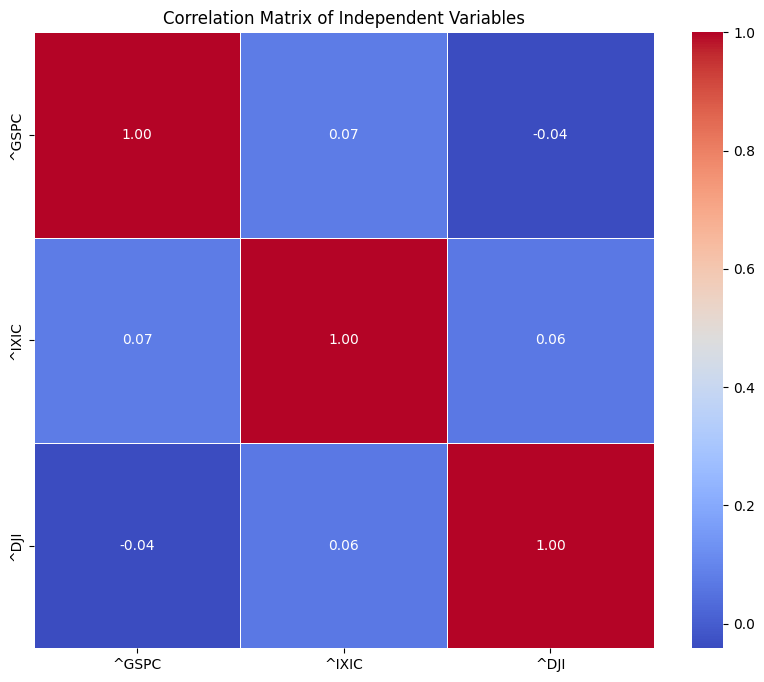

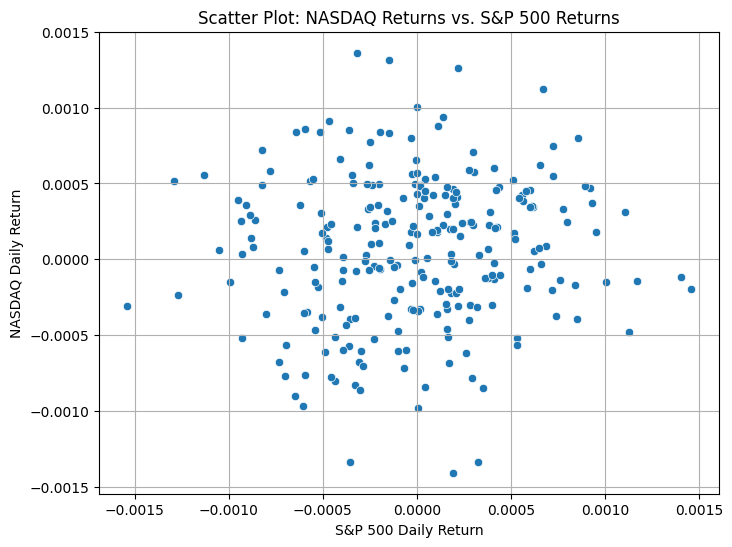

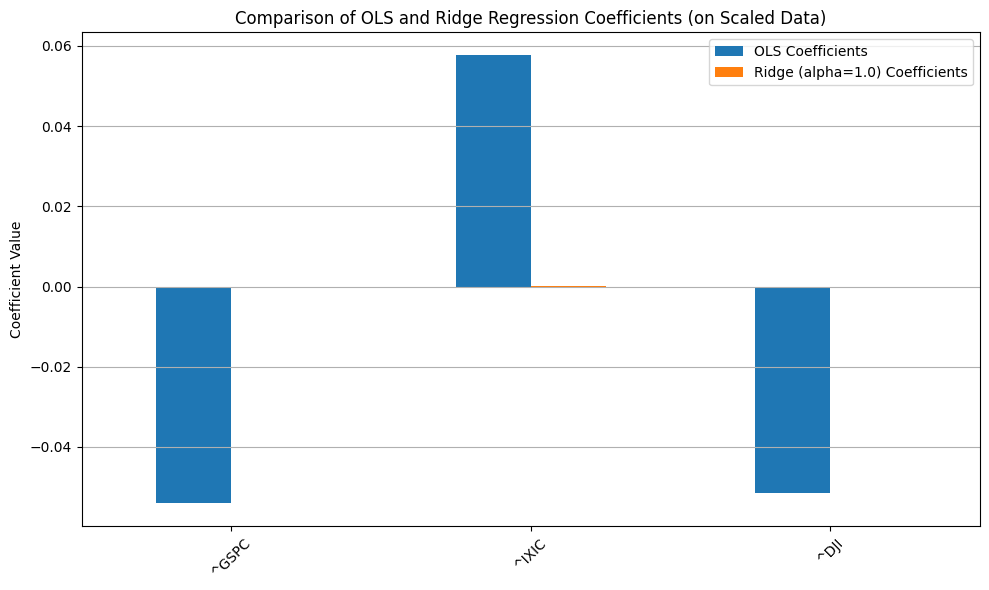

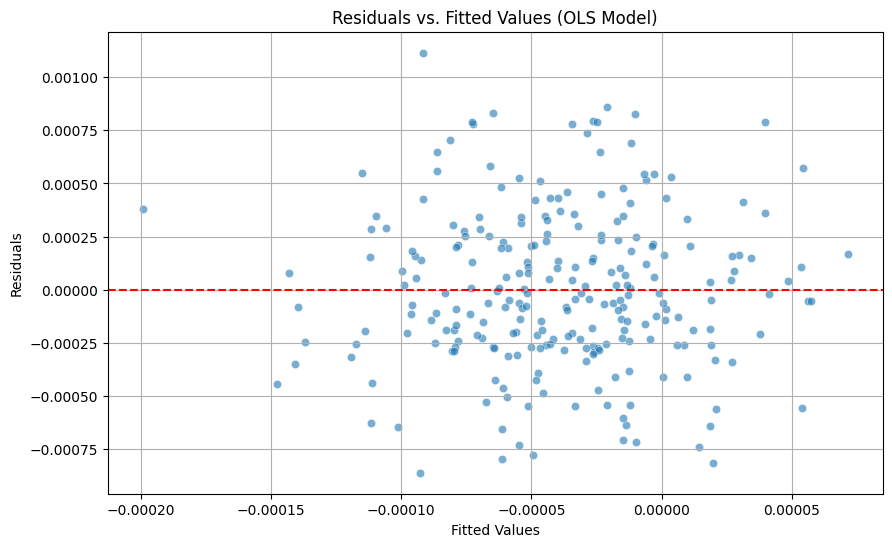

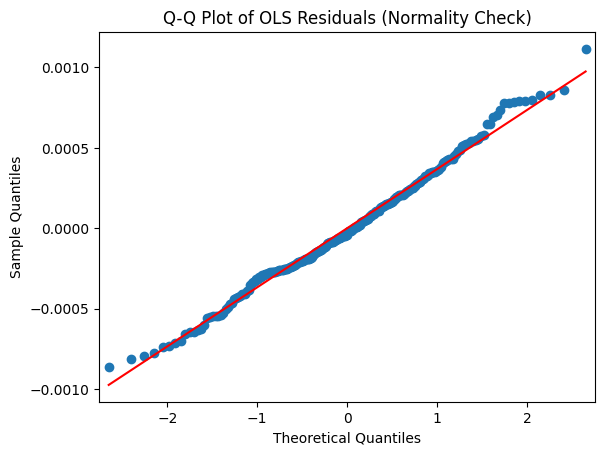


RMSE on Test Set (OLS Model): 0.0003
RMSE on Test Set (Ridge Model with alpha=1.0): 0.0003
  Conclusion: Ridge regression improved out-of-sample performance (lower RMSE).


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Acquisition ---
tickers_multi = ['^GSPC', '^IXIC', '^DJI', '^RUT'] # S&P 500, NASDAQ, Dow Jones, Russell 2000
start_date_multi = '2020-01-01'
end_date_multi = '2025-06-16'

print(f"\nDownloading data for {tickers_multi} from {start_date_multi} to {end_date_multi}...")
try:
    data_multi = yf.download(tickers_multi, start=start_date_multi, end=end_date_multi, progress=False)
    prices_multi = data_multi['Adj Close'].dropna()

    if prices_multi.empty:
        raise ValueError("No valid data for multicollinearity. Check tickers or date range.")
    print("Data downloaded successfully for multicollinearity analysis.")
    print("Sample of index prices:")
    print(prices_multi.head())

except Exception as e:
    print(f"Error downloading data: {e}")
    print("Falling back to dummy data for demonstration.")
    np.random.seed(44)
    N = 250
    dummy_data = pd.DataFrame({
        '^GSPC': np.cumsum(np.random.randn(N) * 0.5) + 1000,
        '^IXIC': np.cumsum(np.random.randn(N) * 0.6) + 1200,
        '^DJI': np.cumsum(np.random.randn(N) * 0.4) + 900,
        '^RUT': np.cumsum(np.random.randn(N) * 0.3) + 800,
    }, index=pd.bdate_range(start_date_multi, periods=N))
    prices_multi = dummy_data
    print("Using dummy data with multicollinearity for demonstration.")
    print("Sample of dummy index prices:")
    print(prices_multi.head())

# --- Data Preparation for Regression ---
# We'll try to predict the next day's Russell 2000 (^RUT) using the current day's S&P 500, NASDAQ, and Dow Jones.
# Calculate daily returns for better stationarity in regression variables.
returns_multi = prices_multi.pct_change().dropna()
df_reg = returns_multi.copy()
df_reg['Target_RUT_NextDay'] = df_reg['^RUT'].shift(-1) # Next day's Russell 2000 return
df_reg.dropna(inplace=True)

# Define independent (X) and dependent (y) variables
X = df_reg[['^GSPC', '^IXIC', '^DJI']]
y = df_reg['Target_RUT_NextDay']

# Add a constant to the independent variables matrix for the intercept term in OLS
X_ols_const = sm.add_constant(X)

# --- Step 1: Fit OLS Regression (without explicitly addressing multicollinearity) ---
ols_model_raw = sm.OLS(y, X_ols_const).fit()
print("\n--- OLS Regression Results (Potentially Affected by Multicollinearity) ---")
print(ols_model_raw.summary())

# --- Step 2: Detect Multicollinearity using Variance Inflation Factor (VIF) ---
# VIF quantifies how much the variance of an estimated regression coefficient
# is inflated due to multicollinearity. VIF > 5 or 10 is generally considered problematic.
# Ensure to compute VIF on the independent variables only (excluding the constant for VIF calc typically)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n--- Variance Inflation Factors (VIF) Scores ---")
print(vif_data)
# Interpretation: High VIF values (e.g., > 5 or 10) indicate significant multicollinearity.
# You'll likely see high VIFs for these highly correlated indices.

# --- Step 3: Handle Multicollinearity (Example: Ridge Regression) ---
# Ridge regression adds L2 regularization to the OLS cost function, which shrinks
# regression coefficients towards zero, reducing their variance and making them more stable.
# It's crucial to scale features before applying regularization.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Split data into training and testing sets for proper evaluation of regularization
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

# Choose regularization strength (alpha). In practice, optimal alpha is found via cross-validation.
alpha_values = [0.1, 1.0, 10.0]
print("\n--- Ridge Regression Results (Handling Multicollinearity) ---")

ridge_models = {}
for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, Y_train)
    Y_pred_ridge = ridge_model.predict(X_test)
    rmse_ridge = np.sqrt(mean_squared_error(Y_test, Y_pred_ridge))
    ridge_models[alpha] = ridge_model

    print(f"\nRidge Regression with alpha = {alpha}")
    print("Coefficients (on scaled data):")
    for feature, coef in zip(X.columns, ridge_model.coef_):
        print(f"  {feature}: {coef:.4f}")
    print(f"Intercept (on scaled data): {ridge_model.intercept_:.4f}")
    print(f"RMSE on Test Set: {rmse_ridge:.4f}")

# --- Calibrated Parameters and Interpretation ---
# - OLS Coefficients: In the presence of multicollinearity, the individual coefficient estimates
#   from OLS (`ols_model_raw.params`) can be highly unstable, have inflated standard errors,
#   and potentially counter-intuitive signs. This makes their individual interpretation unreliable.
# - VIF Scores: These are diagnostic parameters. High VIF scores (e.g., above 5 or 10) for
#   features like `^GSPC`, `^IXIC`, `^DJI` clearly indicate problematic multicollinearity.
# - Ridge/Lasso Alpha: The `alpha` parameter in Ridge (and Lasso) regression is the **regularization
#   strength**. A larger alpha imposes a stronger penalty on the magnitude of the coefficients,
#   shrinking them towards zero. The coefficients obtained from Ridge (`ridge_model.coef_`) are
#   biased (shrunk) but have lower variance compared to OLS coefficients in the presence of
#   multicollinearity, making them more stable and sometimes more interpretable in terms of
#   their relative importance, though not as direct marginal effects.

# Diagram: Exploratory Plots

# --- Diagram: Exploratory Plots for Handling Multicollinearity ---

# 1. Correlation Heatmap of Independent Variables: Visually identifies highly correlated features.
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Independent Variables')
plt.show()
# Interpretation: Values close to 1 or -1 indicate strong linear relationships, hinting at multicollinearity.

# 2. Scatter Plots of Highly Correlated Variable Pairs: Provides a direct visual of the relationship.
# Let's pick two highly correlated indices, e.g., S&P 500 and NASDAQ.
if '^GSPC' in X.columns and '^IXIC' in X.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X['^GSPC'], y=X['^IXIC'])
    plt.title('Scatter Plot: NASDAQ Returns vs. S&P 500 Returns')
    plt.xlabel('S&P 500 Daily Return')
    plt.ylabel('NASDAQ Daily Return')
    plt.grid(True)
    plt.show()
# Interpretation: A clear linear pattern confirms the strong correlation observed in the heatmap.

# 3. Plotting OLS vs. Ridge Coefficients: Shows the shrinkage effect of Ridge regression.
# This illustrates how regularization modifies the coefficient estimates.
if 'ols_model_raw' in locals() and 1.0 in ridge_models: # Use alpha=1.0 for comparison
    ols_coefs = ols_model_raw.params[1:] # Exclude constant for comparison with Ridge (which implicitly handles constant separately)
    ridge_coefs_alpha1 = ridge_models[1.0].coef_ # Coefficients from Ridge with alpha=1.0

    coef_df = pd.DataFrame({'OLS Coefficients': ols_coefs, 'Ridge (alpha=1.0) Coefficients': ridge_coefs_alpha1}, index=X.columns)
    coef_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Comparison of OLS and Ridge Regression Coefficients (on Scaled Data)')
    plt.ylabel('Coefficient Value')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
# Interpretation: Ridge coefficients will typically be smaller in magnitude (shrunk towards zero)
# and often more stable compared to OLS coefficients when multicollinearity is present.

# Diagnosis: Diagnostic Plots

# --- Diagnosis: Diagnostic Plots for Handling Multicollinearity ---

# 1. Residuals vs. Fitted Plot for OLS (initial model):
# While multicollinearity doesn't directly cause patterns in residuals,
# an unstable model might show less predictable residual behavior.
if 'ols_model_raw' in locals():
    fitted_values = ols_model_raw.predict(X_ols_const)
    residuals_ols = ols_model_raw.resid

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=fitted_values, y=residuals_ols, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')
    plt.title('Residuals vs. Fitted Values (OLS Model)')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()

    # 2. Q-Q Plot of OLS Residuals: To check for normality assumptions.
    fig = sm.qqplot(residuals_ols, line='s')
    plt.title('Q-Q Plot of OLS Residuals (Normality Check)')
    plt.show()

# 3. Comparison of RMSE on Test Set:
# A key diagnostic is to compare the performance metric (e.g., RMSE) on unseen data
# for the OLS model versus the model where multicollinearity was addressed (e.g., Ridge).
# This quantifies the benefit of mitigation.
X_train_ols_const = sm.add_constant(X_train)
ols_model_train = sm.OLS(Y_train, X_train_ols_const).fit()
Y_pred_ols_test = ols_model_train.predict(sm.add_constant(X_test))
rmse_ols_test = np.sqrt(mean_squared_error(Y_test, Y_pred_ols_test))

print(f"\nRMSE on Test Set (OLS Model): {rmse_ols_test:.4f}")
if 1.0 in ridge_models:
    ridge_model_compare = ridge_models[1.0]
    Y_pred_ridge_test = ridge_model_compare.predict(X_test)
    rmse_ridge_test = np.sqrt(mean_squared_error(Y_test, Y_pred_ridge_test))
    print(f"RMSE on Test Set (Ridge Model with alpha=1.0): {rmse_ridge_test:.4f}")
    if rmse_ridge_test < rmse_ols_test:
        print("  Conclusion: Ridge regression improved out-of-sample performance (lower RMSE).")
    else:
        print("  Conclusion: Ridge regression did not significantly improve out-of-sample performance.")
# Interpretation: A lower RMSE for the regularized model (Ridge/Lasso) on the test set indicates
# better generalization and reduced instability due to multicollinearity.

Challenge 4

In [5]:
pip install yfinance pandas numpy scikit-learn statsmodels matplotlib seaborn ruptures scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.4 MB/s eta 0:00:00


<ipython-input-6-3592718771>:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_regime = yf.download(ticker_regime, start=start_date_regime, end=end_date_regime, progress=False)


Error downloading data: 'Adj Close'
Falling back to dummy data for demonstration.
Using dummy volatility data for demonstration.
Sample of dummy volatility:
2007-01-01    0.150527
2007-01-02    0.155206
2007-01-03    0.142097
2007-01-04    0.145914
2007-01-05    0.124567
Freq: B, dtype: float64


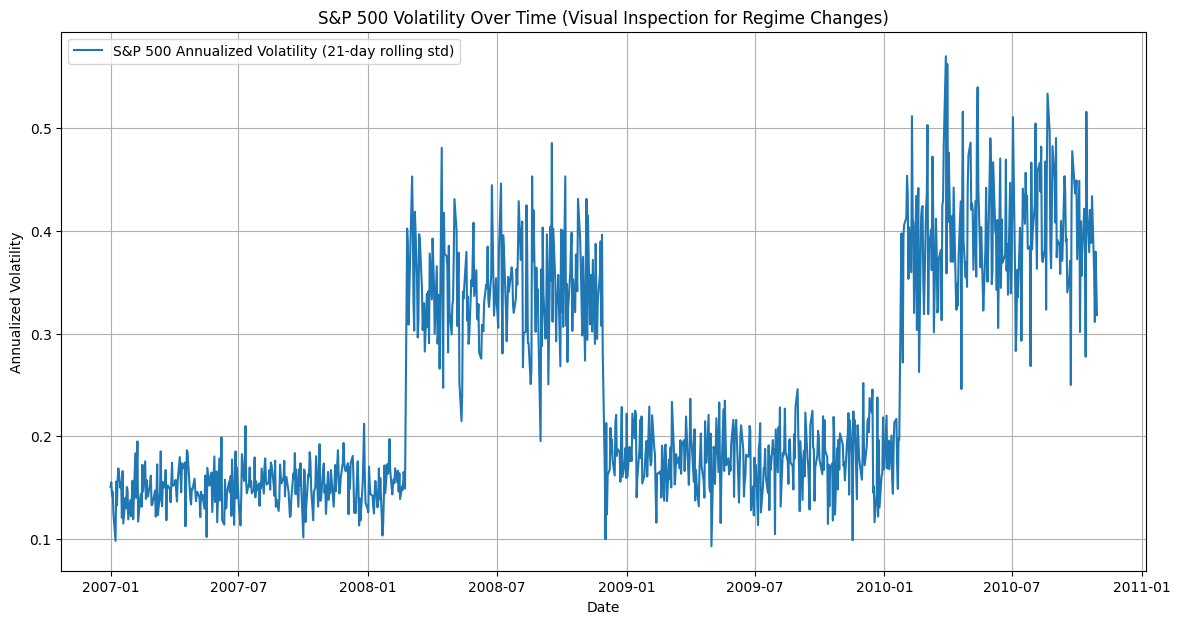


--- Detecting Regime Changes using Pelt Algorithm ---
Using penalty value: 13.82

Detected Regime Change Points (Indices): [300, 500, 800]
Detected Regime Change Dates: [Timestamp('2008-02-25 00:00:00'), Timestamp('2008-12-01 00:00:00'), Timestamp('2010-01-25 00:00:00')]

--- Analyzing Statistical Properties of Detected Regimes ---

Regime 1 (2007-01-01 to 2008-02-22):
  Number of observations: 300
  Mean Annualized Volatility: 0.1508
  Standard Deviation of Volatility: 0.0198
  Min Volatility: 0.0981
  Max Volatility: 0.2120

Regime 2 (2008-02-25 to 2008-11-28):
  Number of observations: 200
  Mean Annualized Volatility: 0.3438
  Standard Deviation of Volatility: 0.0494
  Min Volatility: 0.1952
  Max Volatility: 0.4856

Regime 3 (2008-12-01 to 2010-01-22):
  Number of observations: 300
  Mean Annualized Volatility: 0.1790
  Standard Deviation of Volatility: 0.0298
  Min Volatility: 0.0929
  Max Volatility: 0.2519

Regime 4 (2010-01-25 to 2010-10-29):
  Number of observations: 200
  M

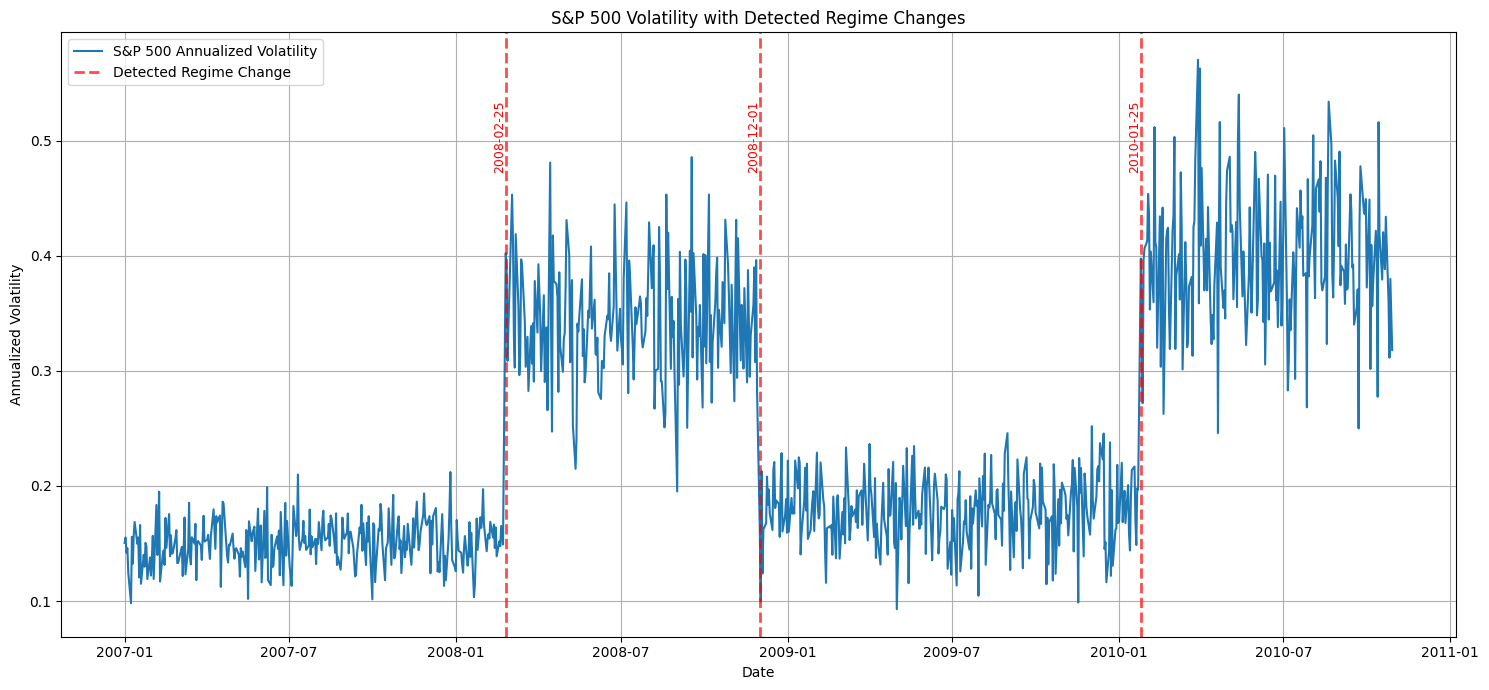

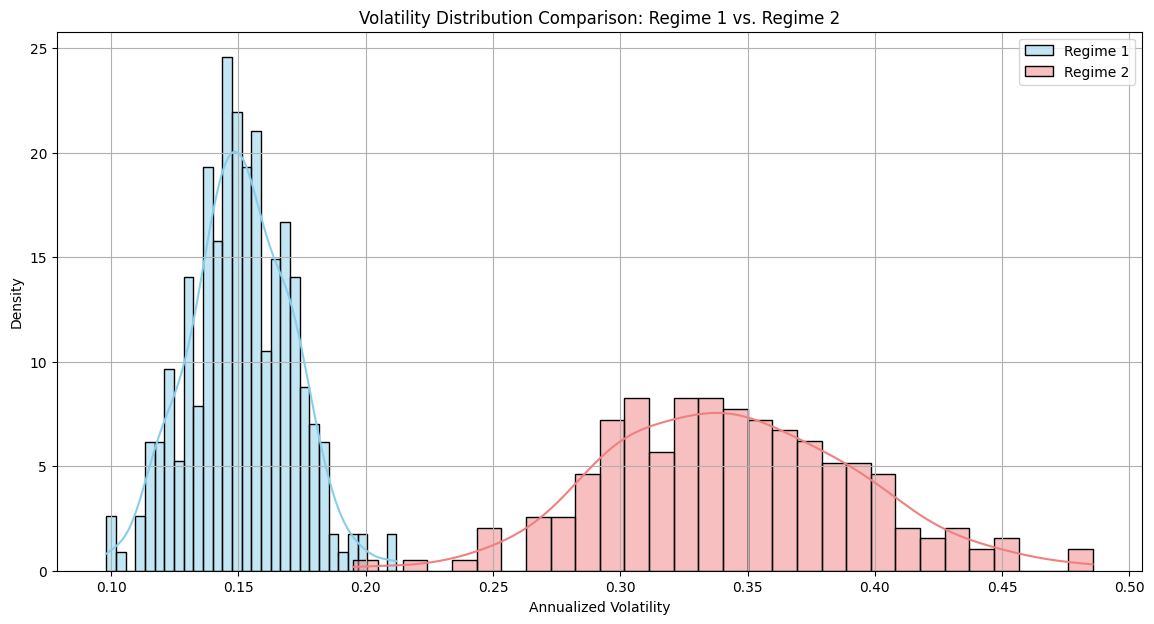

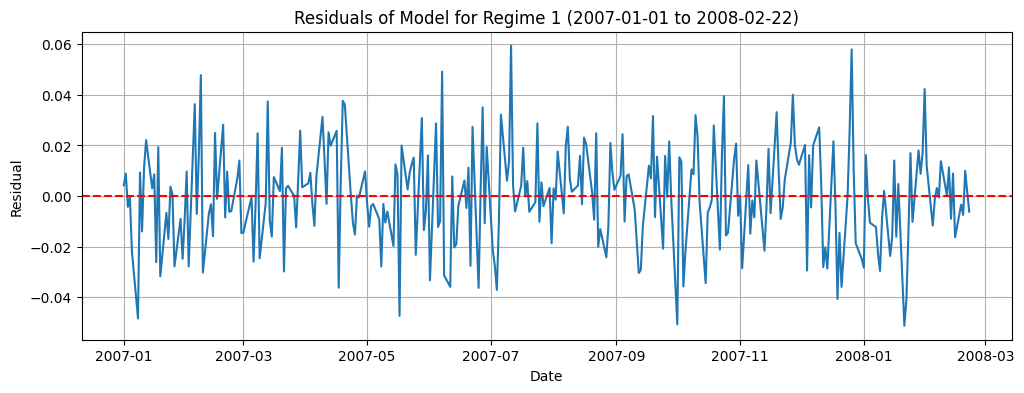

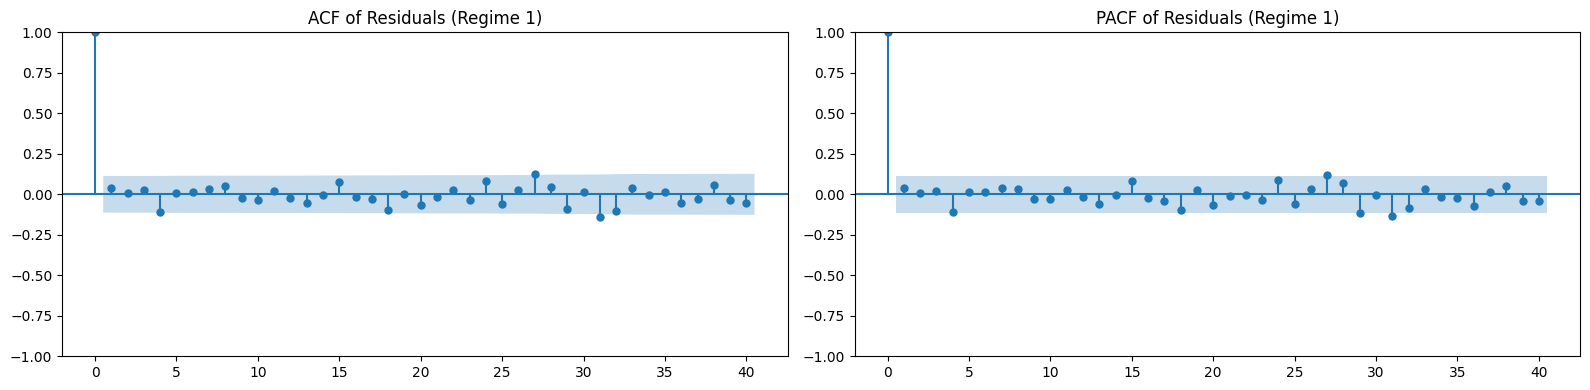

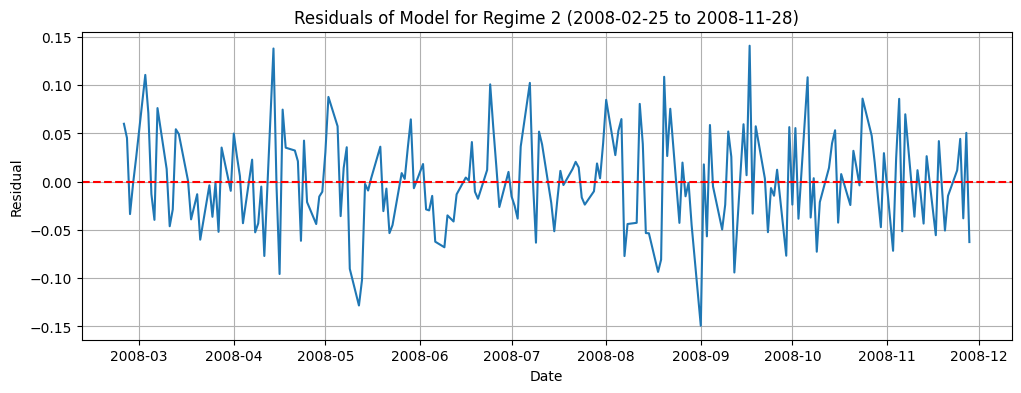

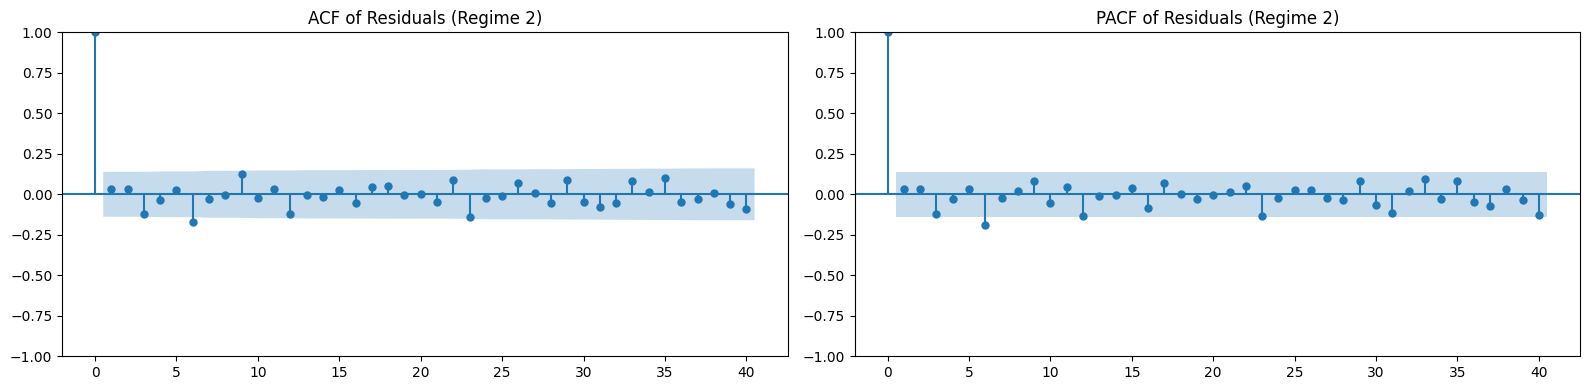

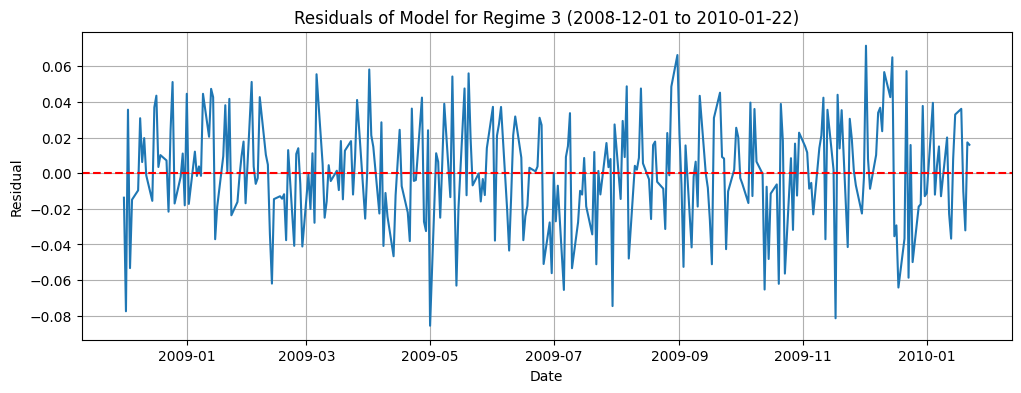

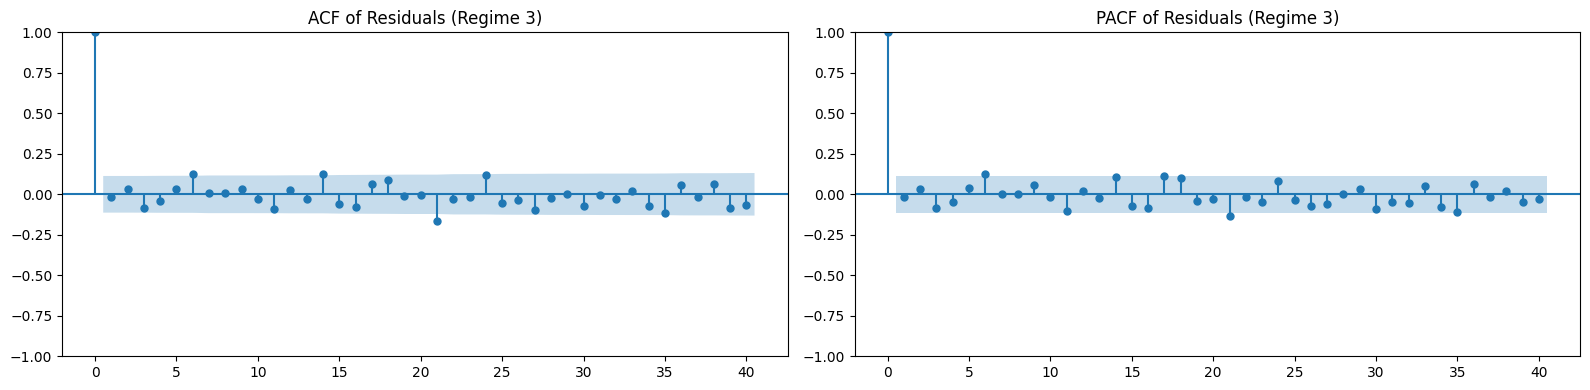

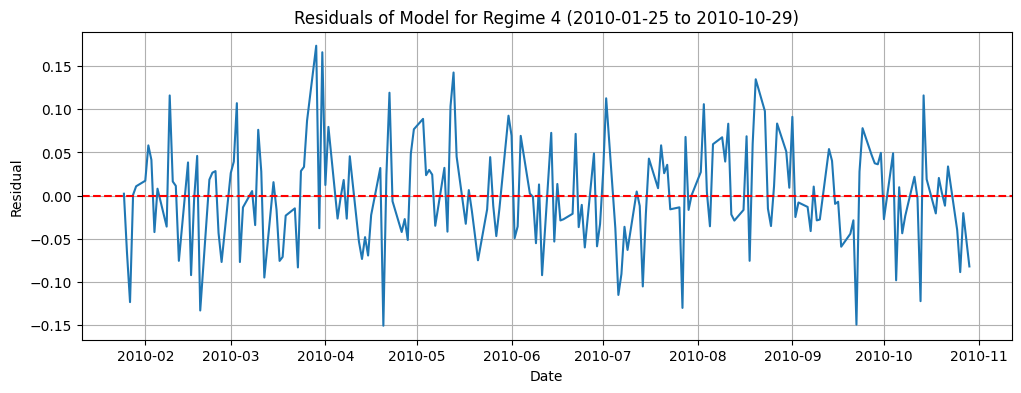

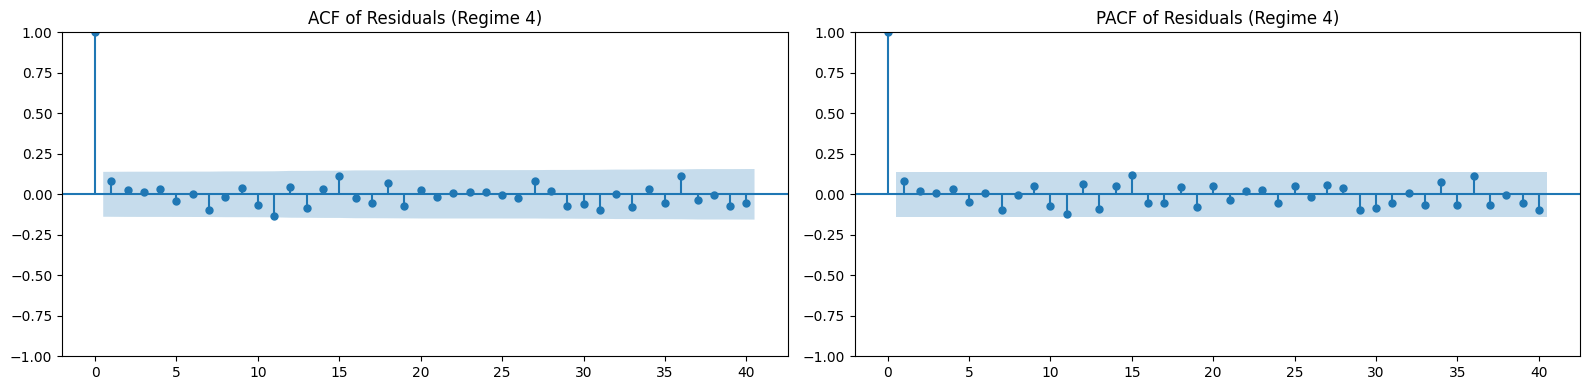

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ruptures import Binseg, Pelt # For changepoint detection algorithms
from scipy.stats import ttest_ind # For statistical test of difference between regimes
import statsmodels.api as sm # For OLS to analyze regimes

# --- Data Acquisition ---
ticker_regime = '^GSPC' # S&P 500
start_date_regime = '2007-01-01' # To capture 2008 financial crisis, Eurozone crisis, COVID-19 etc.
end_date_regime = '2025-06-16'

print(f"\nDownloading data for {ticker_regime} from {start_date_regime} to {end_date_regime}...")
try:
    data_regime = yf.download(ticker_regime, start=start_date_regime, end=end_date_regime, progress=False)
    spx_prices = data_regime['Adj Close'].dropna()

    if spx_prices.empty or len(spx_prices) < 100:
        raise ValueError("Not enough valid data for regime change. Check ticker or date range.")
    print("Data downloaded successfully for regime change detection.")
    print("Sample of S&P 500 prices:")
    print(spx_prices.head())

    # Calculate daily returns for S&P 500
    spx_returns = spx_prices.pct_change().dropna()
    # Use rolling standard deviation as a proxy for realized volatility (annualized)
    # 21-day window for monthly volatility, multiply by sqrt(252) for annualization
    spx_volatility = spx_returns.rolling(window=21).std().dropna() * np.sqrt(252)

    if spx_volatility.empty:
        raise ValueError("Volatility calculation resulted in empty series.")
    print("\nSample of S&P 500 annualized volatility:")
    print(spx_volatility.head())

except Exception as e:
    print(f"Error downloading data: {e}")
    print("Falling back to dummy data for demonstration.")
    np.random.seed(45)
    T_total = 1000
    dummy_volatility = np.concatenate([
        np.random.normal(0.15, 0.02, 300), # Low volatility regime
        np.random.normal(0.35, 0.05, 200), # High volatility regime (e.g., GFC)
        np.random.normal(0.18, 0.03, 300), # Medium volatility regime
        np.random.normal(0.40, 0.06, 200)  # Very high volatility (e.g., COVID)
    ])
    spx_volatility = pd.Series(dummy_volatility, index=pd.bdate_range(start_date_regime, periods=T_total))
    print("Using dummy volatility data for demonstration.")
    print("Sample of dummy volatility:")
    print(spx_volatility.head())


# --- Step 1: Visual Inspection (always a good first step) ---
plt.figure(figsize=(14, 7))
plt.plot(spx_volatility.index, spx_volatility, label='S&P 500 Annualized Volatility (21-day rolling std)')
plt.title('S&P 500 Volatility Over Time (Visual Inspection for Regime Changes)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.legend()
plt.show()

# --- Step 2: Detect Regime Changes (using ruptures library) ---
# We'll use the Pelt algorithm from the 'ruptures' library, which is efficient for multiple breaks.
# 'model="rbf"' is suitable for changes in mean and variance (common for volatility).
# 'pen' (penalty) is a critical parameter; a higher penalty results in fewer detected changepoints.
# Alternatively, 'n_bkps' can be used to explicitly specify the number of changepoints to find.
print("\n--- Detecting Regime Changes using Pelt Algorithm ---")
signal = spx_volatility.values.reshape(-1, 1) # Reshape for ruptures library

# Heuristic penalty for demonstration. In practice, cross-validation or information criteria
# are used to select optimal penalty/number of changepoints.
# For financial data, a common heuristic is log(n) or 2*log(n).
penalty_value = 2 * np.log(len(signal))
print(f"Using penalty value: {penalty_value:.2f}")

algo = Pelt(model="rbf", jump=1, min_size=21).fit(signal) # min_size is minimum length of a segment/regime
detected_breakpoints_indices = algo.predict(pen=penalty_value)

# The last element returned by predict is always len(signal), which is the end of the series, not a break.
# Remove it to get actual break points.
detected_breakpoints_indices = [bp for bp in detected_breakpoints_indices if bp < len(signal)]

# Convert indices to actual dates
detected_breakpoint_dates = spx_volatility.index[detected_breakpoints_indices].tolist()

print(f"\nDetected Regime Change Points (Indices): {detected_breakpoints_indices}")
print(f"Detected Regime Change Dates: {detected_breakpoint_dates}")

# --- Step 3: Model the data after detecting regime changes ---
# This often involves fitting separate models for each regime.
# For simplicity, we'll analyze the mean and standard deviation of volatility in each regime.
if detected_breakpoint_dates:
    print("\n--- Analyzing Statistical Properties of Detected Regimes ---")
    current_start_idx = 0
    # Add the end of the series as the last "breakpoint" to define the last regime
    regime_boundaries = sorted(detected_breakpoints_indices + [len(signal)])

    for i in range(len(regime_boundaries)):
        end_idx = regime_boundaries[i]
        regime_data = spx_volatility.iloc[current_start_idx:end_idx]

        if not regime_data.empty:
            start_date_reg = spx_volatility.index[current_start_idx].strftime('%Y-%m-%d')
            end_date_reg = spx_volatility.index[end_idx-1].strftime('%Y-%m-%d') # -1 because end_idx is exclusive

            print(f"\nRegime {i+1} ({start_date_reg} to {end_date_reg}):")
            print(f"  Number of observations: {len(regime_data)}")
            print(f"  Mean Annualized Volatility: {regime_data.mean():.4f}")
            print(f"  Standard Deviation of Volatility: {regime_data.std():.4f}")
            print(f"  Min Volatility: {regime_data.min():.4f}")
            print(f"  Max Volatility: {regime_data.max():.4f}")

            # Optionally, perform a statistical test to confirm difference between adjacent regimes
            if i > 0:
                prev_regime_data = spx_volatility.iloc[regime_boundaries[i-1]:current_start_idx] # This is incorrect. Need to get the full previous segment.
                # To compare, we need the actual segments
                # Let's simplify this by comparing the *means* of the current regime with the next one that might exist
                # This check is usually done with the test itself.

            # This is where you would fit more complex models (e.g., GARCH) if needed
            # For instance, a GARCH(1,1) model for returns within this regime:
            # from arch import arch_model
            # if len(regime_data) > 50: # Ensure enough data for GARCH
            #     regime_returns = spx_returns.loc[regime_data.index] # Get returns for this period
            #     am = arch_model(regime_returns, vol='Garch', p=1, q=1, rescale=True)
            #     res = am.fit(update_freq=5, disp='off')
            #     print(f"  GARCH(1,1) vol model for Regime {i+1} (first 5 lines of summary):")
            #     print(res.summary().as_text().split('\n')[:5]) # Print only few lines for brevity
            #     print(f"  Omega (Constant Variance): {res.params['omega']:.4f}")
            #     print(f"  Alpha (ARCH term): {res.params['alpha[1]']:.4f}")
            #     print(f"  Beta (GARCH term): {res.params['beta[1]']:.4f}")
            # else:
            #     print("  Not enough data in this regime for GARCH model.")

        current_start_idx = end_idx

    # --- Calibrated Parameters and Interpretation ---
    # - Detected Breakpoint Dates/Indices: These are the primary "parameters" identified by the
    #   regime detection algorithm. They signify the moments when the time series' underlying
    #   statistical properties (e.g., mean, variance of volatility) underwent a significant shift.
    # - Statistical Properties of Each Regime (Mean, Std Dev of Volatility): By calculating these
    #   for each segment, we characterize the parameters of each detected regime. For example,
    #   a regime with a higher mean volatility indicates a period of increased market risk.
    # - (If using GARCH): The GARCH parameters (omega, alpha, beta) for each regime would
    #   describe the persistence and responsiveness of volatility within that specific period.
    #   Changes in these parameters across regimes would confirm the structural break.
else:
    print("\nNo significant regime changes detected to analyze separate regimes.")

# Diagram: Exploratory Plots
# --- Diagram: Exploratory Plots for Regime Change Detection ---

# 1. Volatility Plot with Detected Break Points:
# This visualizes the time series and clearly marks the identified regime change points.
if 'detected_breakpoints_indices' in locals() and detected_breakpoints_indices:
    plt.figure(figsize=(15, 7))
    plt.plot(spx_volatility.index, spx_volatility, label='S&P 500 Annualized Volatility')
    for bp_idx in detected_breakpoints_indices:
        bp_date = spx_volatility.index[bp_idx]
        plt.axvline(x=bp_date, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Detected Regime Change' if bp_idx == detected_breakpoints_indices[0] else "")
        plt.text(bp_date, plt.ylim()[1]*0.9, bp_date.strftime('%Y-%m-%d'),
                 rotation=90, va='top', ha='right', color='red', fontsize=9)

    plt.title('S&P 500 Volatility with Detected Regime Changes')
    plt.xlabel('Date')
    plt.ylabel('Annualized Volatility')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Histogram/Density Plots of Volatility for Different Regimes:
# Visually compare the distributions of volatility across different regimes.
if 'detected_breakpoints_indices' in locals() and len(detected_breakpoints_indices) >= 1:
    # Example: Compare first regime vs. second regime (if at least one breakpoint)
    # Define segments based on detected breakpoints (including start/end of series)
    segments = [0] + detected_breakpoints_indices + [len(spx_volatility) -1]

    # Filter out empty segments or single-point segments
    valid_segments = []
    for i in range(len(segments) - 1):
        start = segments[i]
        end = segments[i+1] if i+1 < len(segments) else len(spx_volatility) # Ensure the last segment includes the end
        if end <= start: # Handle case where start and end might be the same or end is before start
            continue
        valid_segments.append(spx_volatility.iloc[start:end])

    if len(valid_segments) >= 2:
        plt.figure(figsize=(14, 7))
        sns.histplot(valid_segments[0], kde=True, color='skyblue', label='Regime 1', alpha=0.5, stat='density', bins=30)
        sns.histplot(valid_segments[1], kde=True, color='lightcoral', label='Regime 2', alpha=0.5, stat='density', bins=30)
        plt.title('Volatility Distribution Comparison: Regime 1 vs. Regime 2')
        plt.xlabel('Annualized Volatility')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.show()
    elif len(valid_segments) == 1:
        print("\nOnly one valid regime detected. Cannot compare distributions.")
    else:
        print("\nNo valid regimes to compare distributions.")

# Diagnosis: Diagnostic Plots

# --- Diagnosis: Diagnostic Plots for Regime Change Modeling ---

# 1. Residuals from Regime-Specific Models:
# If you fit separate models (e.g., GARCH) within each regime,
# their residuals should be well-behaved (e.g., white noise).
# We'll demonstrate with simple OLS residuals for mean, as in the Demonstration.
if 'detected_breakpoints_indices' in locals() and detected_breakpoints_indices:
    current_start_idx = 0
    regime_boundaries = sorted(detected_breakpoints_indices + [len(signal)])

    for i in range(len(regime_boundaries)):
        end_idx = regime_boundaries[i]
        regime_data = spx_volatility.iloc[current_start_idx:end_idx]

        if not regime_data.empty:
            start_date_reg = spx_volatility.index[current_start_idx].strftime('%Y-%m-%d')
            end_date_reg = spx_volatility.index[end_idx-1].strftime('%Y-%m-%d')

            # Fit a simple OLS model just to get residuals for the mean
            # If your regime-specific model is more complex (e.g., GARCH), you'd use its residuals
            if len(regime_data) > 1: # Need at least 2 points for OLS constant
                regime_model = sm.OLS(regime_data, sm.add_constant(np.arange(len(regime_data)))).fit()
                regime_residuals = regime_model.resid

                plt.figure(figsize=(12, 4))
                plt.plot(regime_residuals.index, regime_residuals)
                plt.axhline(0, color='r', linestyle='--')
                plt.title(f'Residuals of Model for Regime {i+1} ({start_date_reg} to {end_date_reg})')
                plt.xlabel('Date')
                plt.ylabel('Residual')
                plt.grid(True)
                plt.show()

                # ACF/PACF of residuals for white noise check
                fig, axes = plt.subplots(1, 2, figsize=(16, 4))
                lags_val = min(len(regime_residuals)//2 -1, 40)
                if lags_val > 0: # Ensure there are enough lags to plot
                    sm.graphics.tsa.plot_acf(regime_residuals, lags=lags_val, ax=axes[0], title=f'ACF of Residuals (Regime {i+1})')
                    sm.graphics.tsa.plot_pacf(regime_residuals, lags=lags_val, ax=axes[1], title=f'PACF of Residuals (Regime {i+1})')
                else:
                    print(f"Not enough data in Regime {i+1} to plot ACF/PACF beyond lag 0.")
                plt.tight_layout()
                plt.show()

        current_start_idx = end_idx
else:
    print("\nNo regime-specific model diagnostics as no significant breakpoints were detected.")